# Credit Card Default Prediction - Machine Learning Project
## Notebook 01: Problem Definition & Exploratory Data Analysis

**Author:** Daniel Moreira  
**Date:** 2026  
**Course:** Machine Learning  

---

## 1. Problem Definition

### 1.1 Real-World Context

**Domain:** Financial Services - Credit Risk Management

**Business Context:**  
Credit card default is a critical issue in the banking industry. When cardholders fail to make minimum payments for several consecutive months, they are considered to be in default. This results in:
- Direct financial losses for banks
- Increased operational costs for debt collection
- Regulatory capital requirements
- Portfolio risk exposure

**Decision Support:**  
The model will support:
- **Credit approval decisions**: Identifying high-risk applicants
- **Credit limit adjustments**: Reducing limits for at-risk customers
- **Early warning systems**: Flagging customers for proactive intervention
- **Collection prioritization**: Focusing resources on recoverable accounts

### 1.2 Why Machine Learning?

Traditional rule-based systems (e.g., "flag all customers with >3 late payments") are insufficient because:

1. **Complex, Non-Linear Patterns**: Default behavior depends on intricate combinations of demographic factors, payment history, and credit utilization
2. **Multivariate Dependencies**: Variables interact in ways that simple rules cannot capture (e.g., high credit limit + low education + multiple late payments)
3. **Dynamic Risk Profiles**: Customer behavior evolves over time, requiring adaptive models
4. **False Positive Cost**: Fixed thresholds produce too many false alarms, annoying good customers
5. **Scale**: Manual review is impossible for portfolios with millions of accounts

Machine learning enables:
- Automatic discovery of complex risk patterns
- Probabilistic risk scoring rather than binary rules
- Better calibration of precision vs. recall trade-offs

### 1.3 Domain Challenges

1. **Class Imbalance**: Defaults are typically 15-25% of the population, creating imbalanced learning problems
2. **Asymmetric Costs**: 
   - False Negative (missing a default): High cost - actual financial loss
   - False Positive (flagging good customer): Lower cost - potential customer dissatisfaction
3. **Explainability Requirement**: Regulators and customers demand transparency in credit decisions (Fair Credit Reporting Act, GDPR)
4. **Data Quality**: Payment behavior data may contain noise, missing values, or reporting errors
5. **Feature Drift**: Economic conditions change, requiring model retraining

### 1.4 Technical Problem Formulation

**Problem Type:** Binary Classification

**Target Variable:** `default.payment.next.month`
- Class 1: Customer will default (positive class)
- Class 0: Customer will not default (negative class)

**Prediction Horizon:** Next month default probability based on current and historical data

**Justification for Binary Classification:**  
The business decision is binary (approve/deny, increase/decrease limit), and the outcome is binary (default/no default). Multi-class classification or regression would not align with the decision-making process.

---

## 2. Dataset Description

### 2.1 Data Origin

**Source:** UCI Machine Learning Repository  
**Original Study:** Yeh, I. C., & Lien, C. H. (2009). "The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients."  
**Collection:** Important bank in Taiwan, October 2005

### 2.2 Dataset Characteristics

- **Observations:** 30,000 credit card clients
- **Features:** 23 predictor variables
- **Target:** 1 binary outcome variable
- **Temporal Coverage:** 6 months of payment history (April-September 2005)

### 2.3 Feature Description

#### Demographic Features (4):
1. **LIMIT_BAL**: Credit limit (NT dollar)
2. **SEX**: Gender (1=male, 2=female)
3. **EDUCATION**: Education level (1=graduate school, 2=university, 3=high school, 4=others)
4. **MARRIAGE**: Marital status (1=married, 2=single, 3=others)
5. **AGE**: Age in years

#### Payment History Features (6):
6-11. **PAY_0 to PAY_6**: Repayment status from September (PAY_0) to April (PAY_6)
   - Scale: -1=pay duly, 1=payment delay for one month, 2=payment delay for two months, ..., 9=payment delay for nine months and above

#### Bill Amount Features (6):
12-17. **BILL_AMT1 to BILL_AMT6**: Bill statement amount from September (AMT1) to April (AMT6) in NT dollar

#### Previous Payment Features (6):
18-23. **PAY_AMT1 to PAY_AMT6**: Amount of previous payment from September (AMT1) to April (AMT6) in NT dollar

**Total Continuous Variables:** 19 (LIMIT_BAL, AGE, all BILL_AMT and PAY_AMT variables, plus PAY_X can be treated as ordinal/continuous)

**Categorical Variables:** 4 (SEX, EDUCATION, MARRIAGE, PAY_X if treated as categorical)

**Note on Categorical Variables:**  
While SEX, EDUCATION, and MARRIAGE are categorical, they are already encoded as integers and have natural ordinality (especially EDUCATION). We will validate their encoding and potentially use them directly after exploratory analysis.

---

## 3. Setup and Data Loading

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import sys
sys.path.append('..')
from utils import load_credit_data, get_basic_stats

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
# Adjust path as needed based on your file location
df = pd.read_excel('../data/default_of_credit_card_clients.xls', header=1)

# Display basic information
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset loaded successfully!
Shape: (30000, 25)

Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [3]:
# Rename columns for easier handling
df.columns = [
    'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'default'
]

# Display first few rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 4. Exploratory Data Analysis

### 4.1 Basic Dataset Statistics

In [4]:
# Dataset overview
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Number of observations: {len(df):,}")
print(f"Number of features: {len(df.columns)-2}")  # Excluding ID and target
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

DATASET OVERVIEW
Number of observations: 30,000
Number of features: 23

Memory usage: 5.72 MB

Missing values: 0
Duplicate rows: 0


In [5]:
# Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
default      int64
dtype: object


In [6]:
# Descriptive statistics
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### 4.2 Target Variable Analysis

In [7]:
# Target distribution
print("="*60)
print("TARGET VARIABLE ANALYSIS")
print("="*60)

target_counts = df['default'].value_counts()
target_pct = df['default'].value_counts(normalize=True) * 100

print(f"\nClass Distribution:")
print(f"  No Default (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"  Default (1):    {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\nImbalance Ratio: {target_counts[0]/target_counts[1]:.2f}:1")
print(f"\n⚠️  CLASS IMBALANCE IDENTIFIED: This will require careful handling")

TARGET VARIABLE ANALYSIS

Class Distribution:
  No Default (0): 23,364 (77.88%)
  Default (1):    6,636 (22.12%)

Imbalance Ratio: 3.52:1

⚠️  CLASS IMBALANCE IDENTIFIED: This will require careful handling


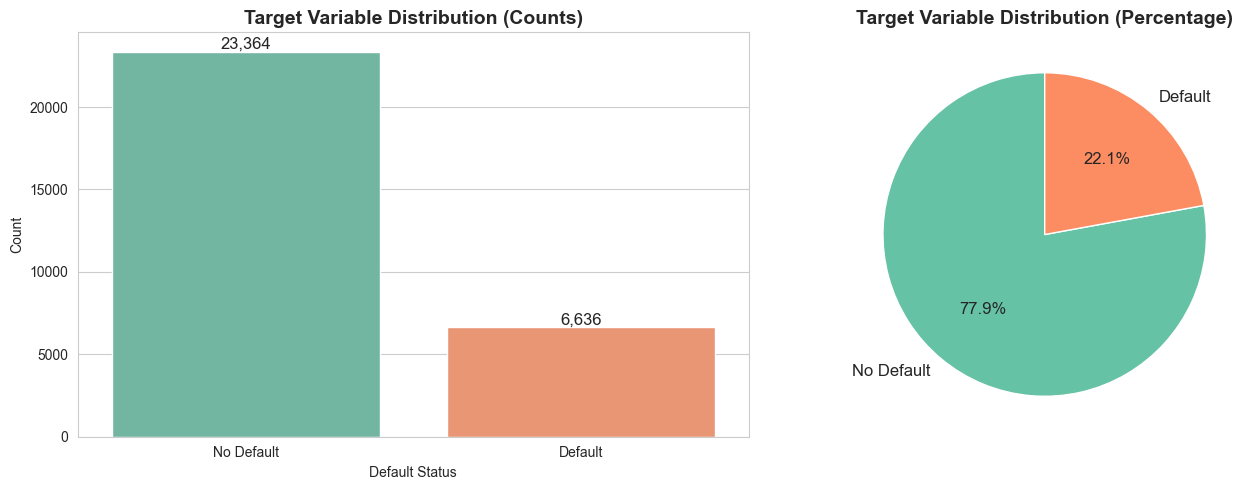

In [8]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='default', ax=axes[0], palette='Set2')
axes[0].set_title('Target Variable Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Default Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default', 'Default'])

# Add count labels
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)

# Pie chart
colors = sns.color_palette('Set2')
axes[1].pie(target_counts, labels=['No Default', 'Default'], autopct='%1.1f%%',
           startangle=90, colors=colors, textprops={'fontsize': 12})
axes[1].set_title('Target Variable Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 Feature Analysis

#### 4.3.1 Demographic Features

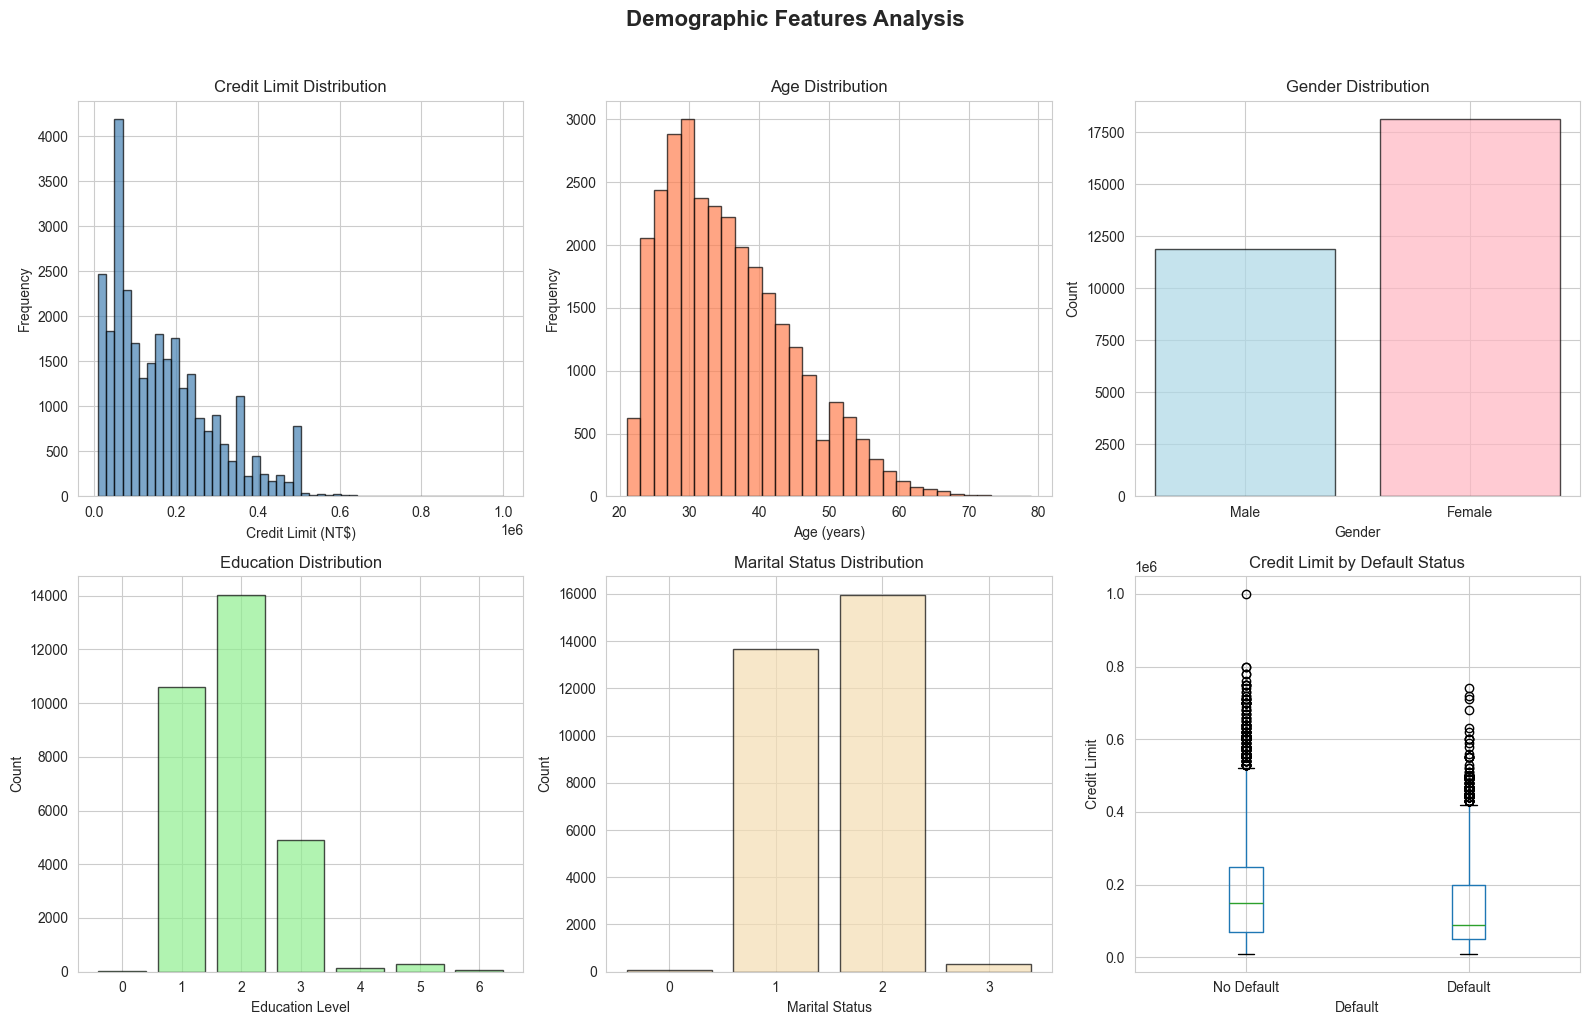

In [9]:
# Demographic features distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Credit Limit
axes[0].hist(df['LIMIT_BAL'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Credit Limit Distribution')
axes[0].set_xlabel('Credit Limit (NT$)')
axes[0].set_ylabel('Frequency')

# Age
axes[1].hist(df['AGE'], bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Frequency')

# Gender
sex_counts = df['SEX'].value_counts().sort_index()
axes[2].bar([1, 2], sex_counts.values, color=['lightblue', 'lightpink'], alpha=0.7, edgecolor='black')
axes[2].set_title('Gender Distribution')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Count')
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Male', 'Female'])

# Education
edu_counts = df['EDUCATION'].value_counts().sort_index()
axes[3].bar(edu_counts.index, edu_counts.values, color='lightgreen', alpha=0.7, edgecolor='black')
axes[3].set_title('Education Distribution')
axes[3].set_xlabel('Education Level')
axes[3].set_ylabel('Count')
axes[3].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes[3].set_xticklabels([0, 1, 2, 3, 4, 5, 6])

# Marriage
mar_counts = df['MARRIAGE'].value_counts().sort_index()
axes[4].bar(mar_counts.index, mar_counts.values, color='wheat', alpha=0.7, edgecolor='black')
axes[4].set_title('Marital Status Distribution')
axes[4].set_xlabel('Marital Status')
axes[4].set_ylabel('Count')
axes[4].set_xticks([0, 1, 2, 3])
axes[4].set_xticklabels([0, 1, 2, 3])

# Credit Limit by Default Status
df.boxplot(column='LIMIT_BAL', by='default', ax=axes[5])
axes[5].set_title('Credit Limit by Default Status')
axes[5].set_xlabel('Default')
axes[5].set_ylabel('Credit Limit')
axes[5].set_xticks([1, 2])
axes[5].set_xticklabels(['No Default', 'Default'])

plt.suptitle('Demographic Features Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### 4.3.2 Payment History Analysis

In [10]:
# Analyze payment history features
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("Payment History Summary:")
print(df[pay_cols].describe())

# Check unique values
print("\nUnique values in payment features:")
for col in pay_cols:
    print(f"{col}: {sorted(df[col].unique())}")

Payment History Summary:
              PAY_0         PAY_2         PAY_3         PAY_4         PAY_5  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      -0.016700     -0.133767     -0.166200     -0.220667     -0.266200   
std        1.123802      1.197186      1.196868      1.169139      1.133187   
min       -2.000000     -2.000000     -2.000000     -2.000000     -2.000000   
25%       -1.000000     -1.000000     -1.000000     -1.000000     -1.000000   
50%        0.000000      0.000000      0.000000      0.000000      0.000000   
75%        0.000000      0.000000      0.000000      0.000000      0.000000   
max        8.000000      8.000000      8.000000      8.000000      8.000000   

              PAY_6  
count  30000.000000  
mean      -0.291100  
std        1.149988  
min       -2.000000  
25%       -1.000000  
50%        0.000000  
75%        0.000000  
max        8.000000  

Unique values in payment features:
PAY_0: [np.int64(-2), np.int6

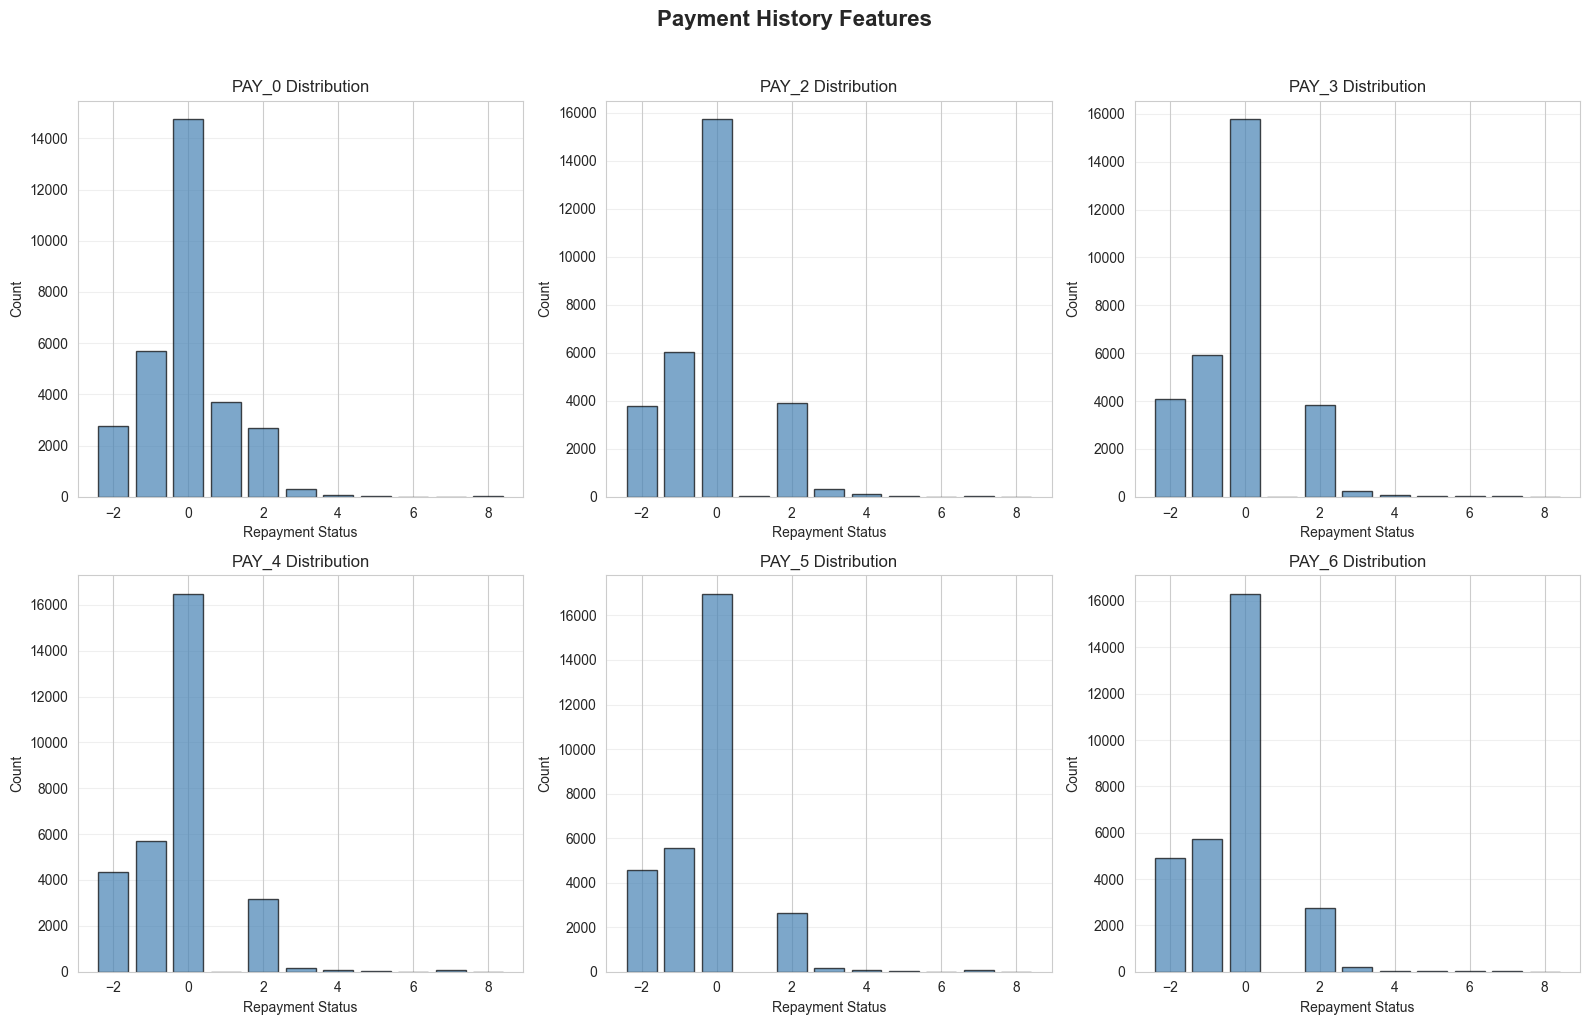

In [11]:
# Visualize payment history
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(pay_cols):
    pay_counts = df[col].value_counts().sort_index()
    axes[idx].bar(pay_counts.index, pay_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel('Repayment Status')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Payment History Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 4.3.3 Bill Amount and Payment Amount Analysis

In [12]:
# Bill amounts
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

print("Bill Amount Summary:")
print(df[bill_cols].describe())

print("\n" + "="*60)
print("Payment Amount Summary:")
print(df[pay_amt_cols].describe())

Bill Amount Summary:
           BILL_AMT1      BILL_AMT2     BILL_AMT3      BILL_AMT4  \
count   30000.000000   30000.000000  3.000000e+04   30000.000000   
mean    51223.330900   49179.075167  4.701315e+04   43262.948967   
std     73635.860576   71173.768783  6.934939e+04   64332.856134   
min   -165580.000000  -69777.000000 -1.572640e+05 -170000.000000   
25%      3558.750000    2984.750000  2.666250e+03    2326.750000   
50%     22381.500000   21200.000000  2.008850e+04   19052.000000   
75%     67091.000000   64006.250000  6.016475e+04   54506.000000   
max    964511.000000  983931.000000  1.664089e+06  891586.000000   

           BILL_AMT5      BILL_AMT6  
count   30000.000000   30000.000000  
mean    40311.400967   38871.760400  
std     60797.155770   59554.107537  
min    -81334.000000 -339603.000000  
25%      1763.000000    1256.000000  
50%     18104.500000   17071.000000  
75%     50190.500000   49198.250000  
max    927171.000000  961664.000000  

Payment Amount Summary:

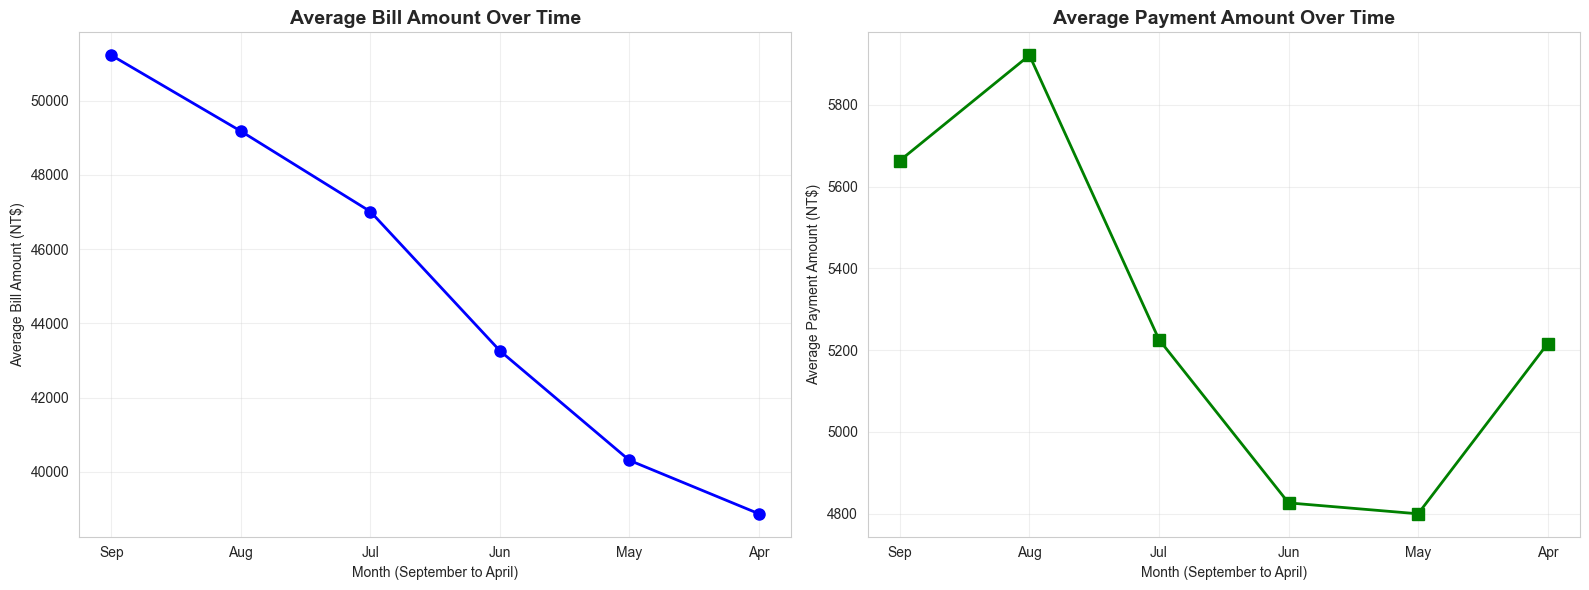

In [13]:
# Visualize bill and payment amounts over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bill amounts
df[bill_cols].mean().plot(kind='line', marker='o', ax=axes[0], color='blue', linewidth=2, markersize=8)
axes[0].set_title('Average Bill Amount Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month (September to April)')
axes[0].set_ylabel('Average Bill Amount (NT$)')
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr'])
axes[0].grid(alpha=0.3)

# Payment amounts
df[pay_amt_cols].mean().plot(kind='line', marker='s', ax=axes[1], color='green', linewidth=2, markersize=8)
axes[1].set_title('Average Payment Amount Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month (September to April)')
axes[1].set_ylabel('Average Payment Amount (NT$)')
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 4.4 Correlation Analysis

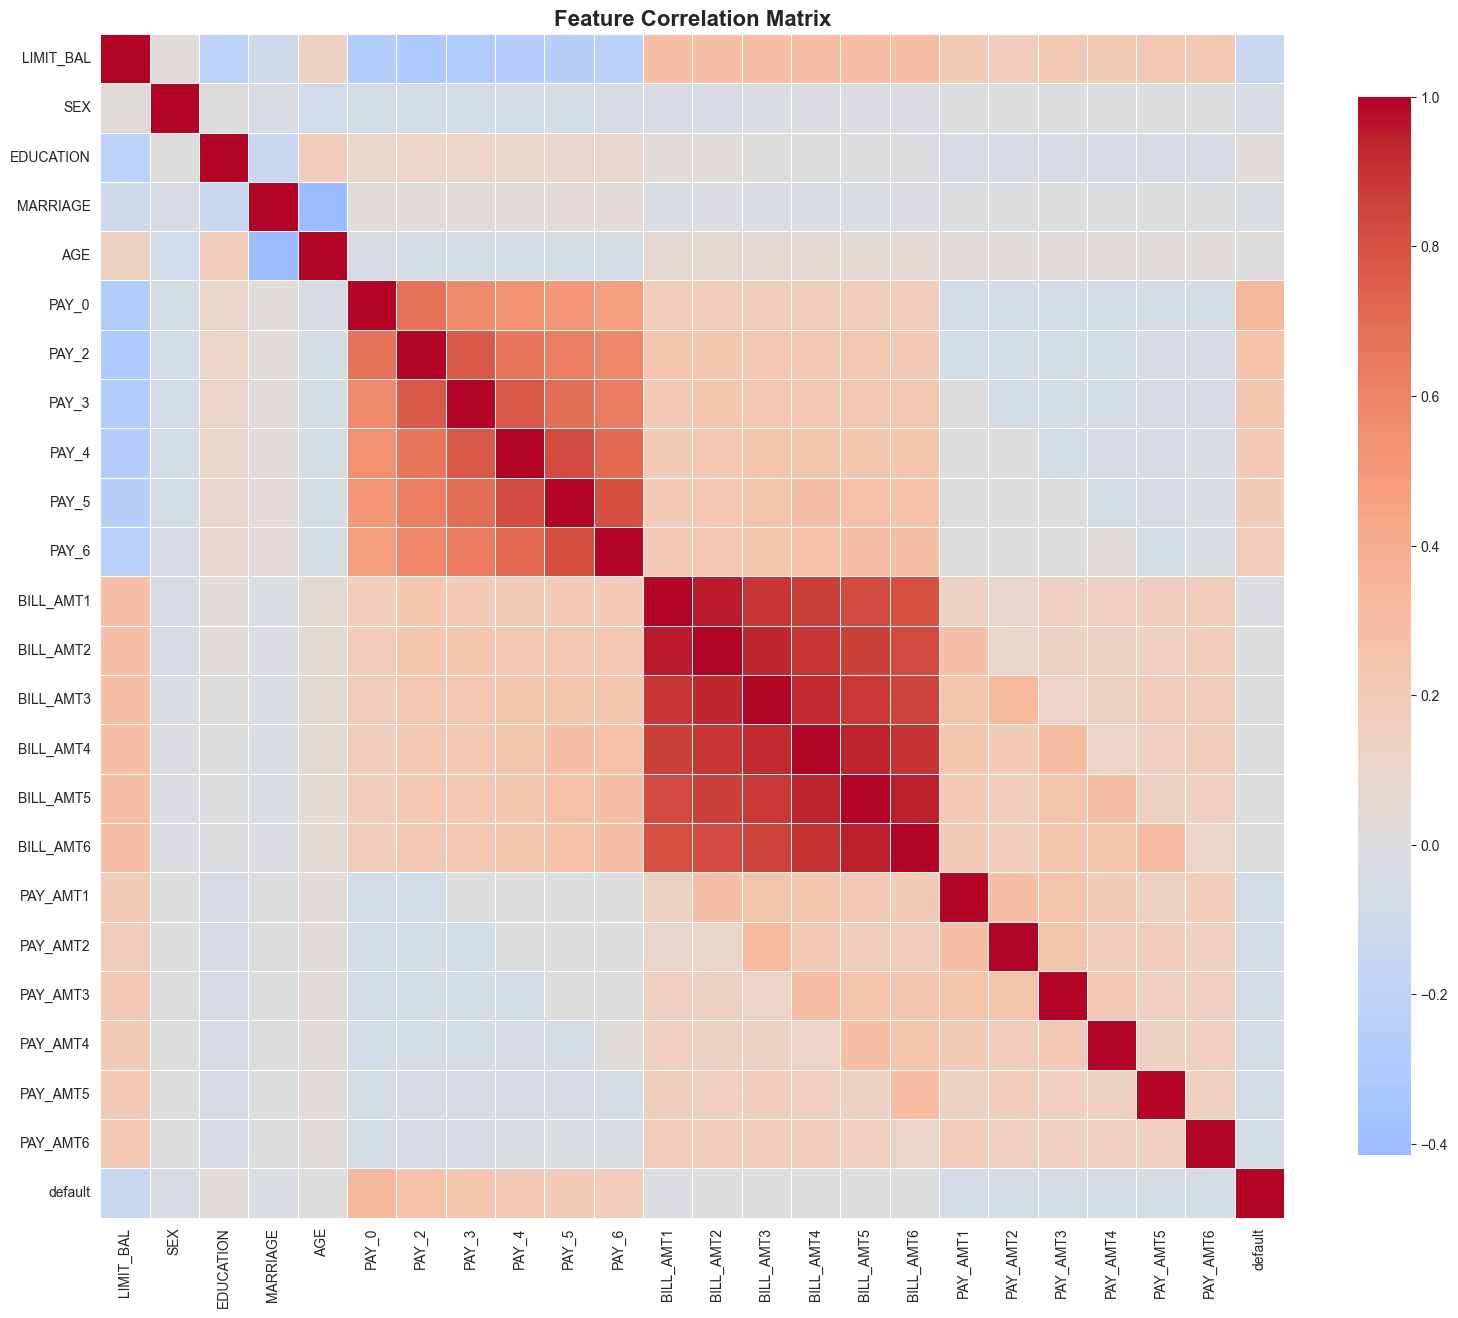

In [14]:
# Compute correlation matrix
correlation_matrix = df.drop('ID', axis=1).corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 Features Correlated with Default:
default      1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
Name: default, dtype: float64


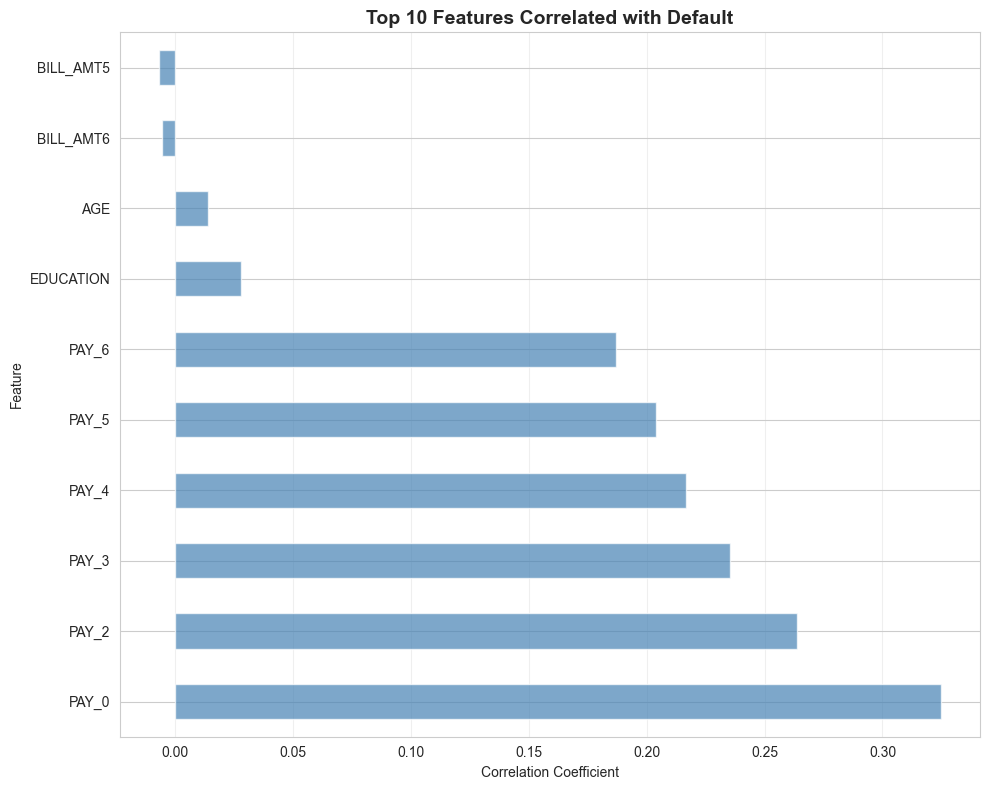

In [15]:
# Correlation with target variable
target_corr = correlation_matrix['default'].sort_values(ascending=False)

print("Top 10 Features Correlated with Default:")
print(target_corr.head(11))  # 11 to exclude 'default' itself

# Visualize
plt.figure(figsize=(10, 8))
target_corr[1:11].plot(kind='barh', color='steelblue', alpha=0.7)
plt.title('Top 10 Features Correlated with Default', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Feature Engineering Considerations

In [16]:
# Create some derived features for analysis
df_analysis = df.copy()

# Credit utilization (average bill / limit)
df_analysis['avg_bill'] = df_analysis[bill_cols].mean(axis=1)
df_analysis['credit_utilization'] = df_analysis['avg_bill'] / df_analysis['LIMIT_BAL']

# Payment ratio (average payment / average bill)
df_analysis['avg_payment'] = df_analysis[pay_amt_cols].mean(axis=1)
df_analysis['payment_ratio'] = df_analysis['avg_payment'] / (df_analysis['avg_bill'] + 1)

# Number of times payment delayed
df_analysis['num_delays'] = (df_analysis[pay_cols] > 0).sum(axis=1)

print("Derived Features Created:")
print("- credit_utilization: Average bill amount / Credit limit")
print("- payment_ratio: Average payment / Average bill")
print("- num_delays: Number of months with payment delay")

print("\nCorrelation of derived features with default:")
derived_cols = ['credit_utilization', 'payment_ratio', 'num_delays']
for col in derived_cols:
    corr = df_analysis[[col, 'default']].corr().iloc[0, 1]
    print(f"{col}: {corr:.4f}")

Derived Features Created:
- credit_utilization: Average bill amount / Credit limit
- payment_ratio: Average payment / Average bill
- num_delays: Number of months with payment delay

Correlation of derived features with default:
credit_utilization: 0.1155
payment_ratio: -0.0071
num_delays: 0.3984


## 5. Data Quality Assessment

In [17]:
# Check for outliers in continuous features
continuous_features = ['LIMIT_BAL', 'AGE'] + bill_cols + pay_amt_cols

print("Outlier Detection (using IQR method):")
print("="*60)

for feature in continuous_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    
    if len(outliers) > 0:
        print(f"{feature}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

Outlier Detection (using IQR method):
LIMIT_BAL: 167 outliers (0.56%)
AGE: 272 outliers (0.91%)
BILL_AMT1: 2400 outliers (8.00%)
BILL_AMT2: 2395 outliers (7.98%)
BILL_AMT3: 2469 outliers (8.23%)
BILL_AMT4: 2622 outliers (8.74%)
BILL_AMT5: 2725 outliers (9.08%)
BILL_AMT6: 2693 outliers (8.98%)
PAY_AMT1: 2745 outliers (9.15%)
PAY_AMT2: 2714 outliers (9.05%)
PAY_AMT3: 2598 outliers (8.66%)
PAY_AMT4: 2994 outliers (9.98%)
PAY_AMT5: 2945 outliers (9.82%)
PAY_AMT6: 2958 outliers (9.86%)


In [18]:
# Check for anomalies in categorical features
print("\nCategorical Feature Value Distributions:")
print("="*60)

print("\nSEX (should be 1 or 2):")
print(df['SEX'].value_counts().sort_index())

print("\nEDUCATION (should be 1-4):")
print(df['EDUCATION'].value_counts().sort_index())

print("\nMARRIAGE (should be 1-3):")
print(df['MARRIAGE'].value_counts().sort_index())

print("\n⚠️  Note: Values outside expected ranges (e.g., EDUCATION=0,5,6) may represent 'others' or data quality issues")


Categorical Feature Value Distributions:

SEX (should be 1 or 2):
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION (should be 1-4):
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE (should be 1-3):
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

⚠️  Note: Values outside expected ranges (e.g., EDUCATION=0,5,6) may represent 'others' or data quality issues


## 6. Key Findings and Insights

### 6.1 Data Quality
- ✅ No missing values detected
- ✅ No duplicate records
- ⚠️ Some categorical features have unexpected values (EDUCATION: 0,5,6; MARRIAGE: 0)
- ⚠️ Outliers present in bill and payment amounts (expected for financial data)

### 6.2 Target Variable
- **Class Imbalance:** ~22% default rate (approximately 3.5:1 ratio)
- **Implication:** Models may be biased toward the majority class (no default)
- **Strategy:** Will need to monitor precision and recall carefully, not just accuracy

### 6.3 Feature Insights

**Strong Predictors (based on correlation):**
1. Payment history (PAY_0 through PAY_6) - Higher delay months correlate with default
2. Credit limit - Lower limits correlate with higher default risk
3. Age - Younger customers show slightly higher default rates

**Weak Predictors:**
- Gender shows minimal correlation
- Individual bill/payment amounts less predictive than payment behavior

**Feature Relationships:**
- Bill amounts show strong inter-correlation (expected - same customer over time)
- Payment amounts also highly correlated with each other
- Payment history variables show moderate correlation

### 6.4 Domain-Specific Observations

1. **Credit Utilization:** Customers with higher utilization (bill/limit ratio) tend to default more
2. **Payment Consistency:** The most recent payment behavior (PAY_0) is most predictive
3. **Risk Accumulation:** Customers with multiple months of delayed payments are high-risk
4. **Demographic Patterns:** Education and marital status show some correlation with default

---

## 7. Data Preparation for Modeling

Based on our EDA, we will:

1. **Keep all features** except ID (which is just an identifier)
2. **Address categorical encoding** in the next notebook during preprocessing
3. **Monitor class imbalance** through appropriate metrics (precision, recall, F1)
4. **Consider feature scaling** for distance-based models
5. **Validate model interpretability** to ensure regulatory compliance

The dataset has **23 usable features**, satisfying the project requirement of at least 10 features for multivariate analysis and future PCA application.

---

## 8. Save Cleaned Dataset

In [19]:
# Save cleaned dataset for next notebooks
df.to_csv('../data/credit_card_cleaned.csv', index=False)
print("✅ Cleaned dataset saved to '../data/credit_card_cleaned.csv'")
print(f"Shape: {df.shape}")

✅ Cleaned dataset saved to '../data/credit_card_cleaned.csv'
Shape: (30000, 25)


## Summary

In this notebook, we:

1. ✅ Defined the credit card default prediction problem in its real-world context
2. ✅ Justified the use of machine learning over rule-based systems
3. ✅ Described the dataset (30,000 observations, 23 features)
4. ✅ Identified domain challenges (class imbalance, explainability, asymmetric costs)
5. ✅ Performed comprehensive exploratory data analysis
6. ✅ Analyzed feature distributions and relationships
7. ✅ Assessed data quality (no missing values, some outliers)
8. ✅ Identified key predictors (payment history, credit limit)

**Next Steps:** Notebook 02 - Baseline Perceptron Model

---